In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/diamonds.csv")

In [3]:
# exploring the dataset

In [4]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [6]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
df.shape

(53940, 11)

In [8]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [9]:
# checking and filling the missing values

In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [11]:
# finding and removing the duplicates

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
# detecting outliers
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)]
print(lower)
print(upper)

-5611.375
11885.625


In [16]:
# statistical calculations

In [18]:
df.mean(numeric_only=True)

,0
Unnamed: 0,27054.875000
carat,0.723657
depth,61.755603
table,57.421873
price,3159.460833
x,5.582965
y,5.586255
z,3.448359


In [19]:
df.median(numeric_only=True)

,0
Unnamed: 0,28740.50
carat,0.70
depth,61.80
table,57.00
price,2155.00
x,5.59
y,5.57
z,3.43


In [20]:
df.mode().iloc[0]

,0
Unnamed: 0,1
carat,0.3
cut,Ideal
color,G
clarity,SI1
depth,62.0
table,56.0
price,605.0
x,4.37
y,4.34


In [21]:
df.var(numeric_only=True)

,0
Unnamed: 0,2.592966e+08
carat,1.472697e-01
depth,2.047131e+00
table,4.970288e+00
price,7.643568e+06
x,9.897702e-01
y,9.879101e-01
z,3.974321e-01


In [22]:
df.std(numeric_only=True)

,0
Unnamed: 0,16102.688258
carat,0.383757
depth,1.430780
table,2.229414
price,2764.700316
x,0.994872
y,0.993937
z,0.630422


In [23]:
# analyzing numerical and categorical features

In [24]:
# numerical
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000
mean,27054.875000,0.723657,61.755603,57.421873,3159.460833,5.582965,5.586255,3.448359
std,16102.688258,0.383757,1.430780,2.229414,2764.700316,0.994872,0.993937,0.630422
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,12600.750000,0.380000,61.100000,56.000000,911.000000,4.670000,4.680000,2.880000
50%,28740.500000,0.700000,61.800000,57.000000,2155.000000,5.590000,5.570000,3.430000
75%,41340.250000,1.010000,62.500000,59.000000,4669.000000,6.430000,6.420000,3.980000
max,53940.000000,3.650000,79.000000,79.000000,11883.000000,9.540000,31.800000,31.800000


In [25]:
df['cut'].value_counts()

,count
cut,
Ideal,20392
Premium,12533
Very Good,11325
Good,4641
Fair,1509


In [26]:
df['color'].value_counts()

,count
color,
G,10554
E,9429
F,9022
H,7641
D,6508
I,4789
J,2457


In [27]:
df['clarity'].value_counts()

,count
clarity,
SI1,12275
VS2,11413
SI2,8214
VS1,7700
VVS2,4848
VVS1,3536
IF,1687
I1,727


In [28]:
# correlation matrix
df.corr(numeric_only=True)

,Unnamed: 0,carat,depth,table,price,x,y,z
Unnamed: 0,1.000000,-0.469400,-0.036216,-0.103444,-0.439486,-0.462140,-0.459657,-0.451844
carat,-0.469400,1.000000,0.046375,0.183691,0.915825,0.980767,0.972894,0.956139
depth,-0.036216,0.046375,1.000000,-0.291932,0.004075,-0.016122,-0.019462,0.115112
table,-0.103444,0.183691,-0.291932,1.000000,0.128120,0.193302,0.184486,0.144526
price,-0.439486,0.915825,0.004075,0.128120,1.000000,0.895808,0.891479,0.869637
x,-0.462140,0.980767,-0.016122,0.193302,0.895808,1.000000,0.990768,0.965714
y,-0.459657,0.972894,-0.019462,0.184486,0.891479,0.990768,1.000000,0.959671
z,-0.451844,0.956139,0.115112,0.144526,0.869637,0.965714,0.959671,1.000000


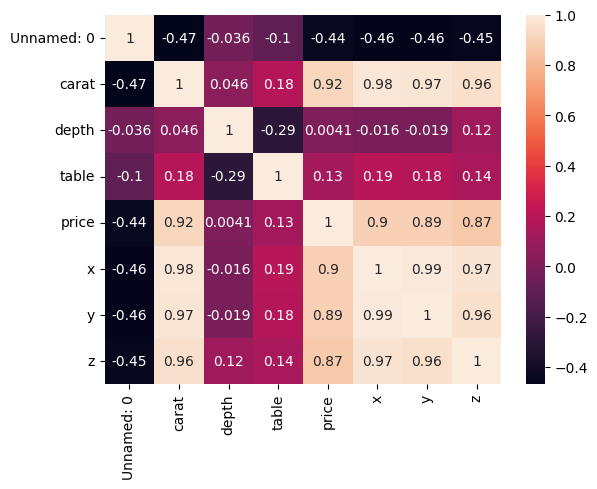

In [29]:
# heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


In [30]:
# visualization

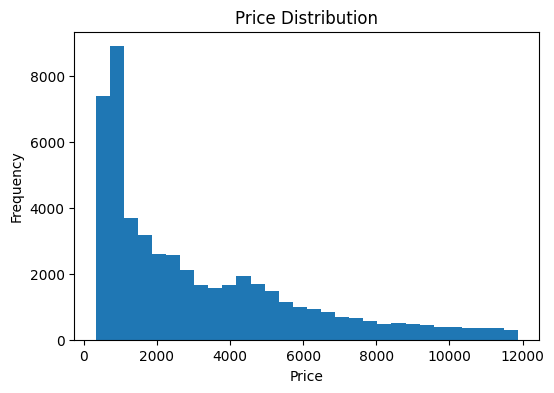

In [31]:
plt.figure(figsize=(6,4))
plt.hist(df['price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

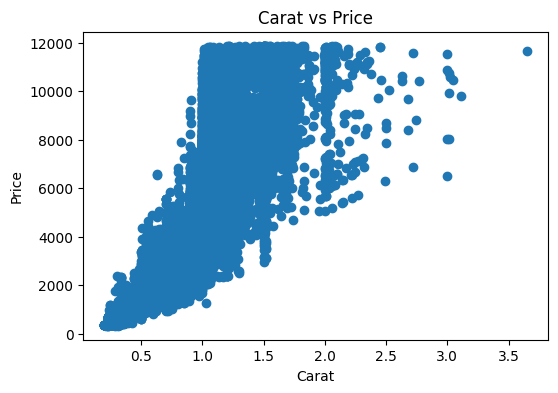

In [32]:
plt.figure(figsize=(6,4))
plt.scatter(df['carat'], df['price'])
plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Carat vs Price")
plt.show()

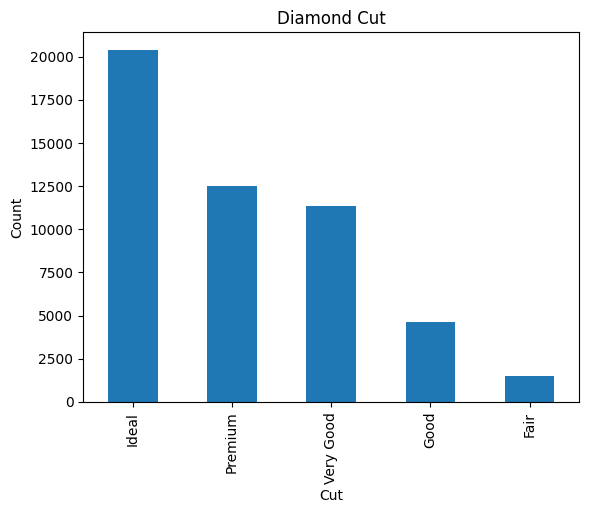

In [33]:
df['cut'].value_counts().plot(kind='bar')
plt.title("Diamond Cut")
plt.xlabel("Cut")
plt.ylabel("Count")
plt.show()

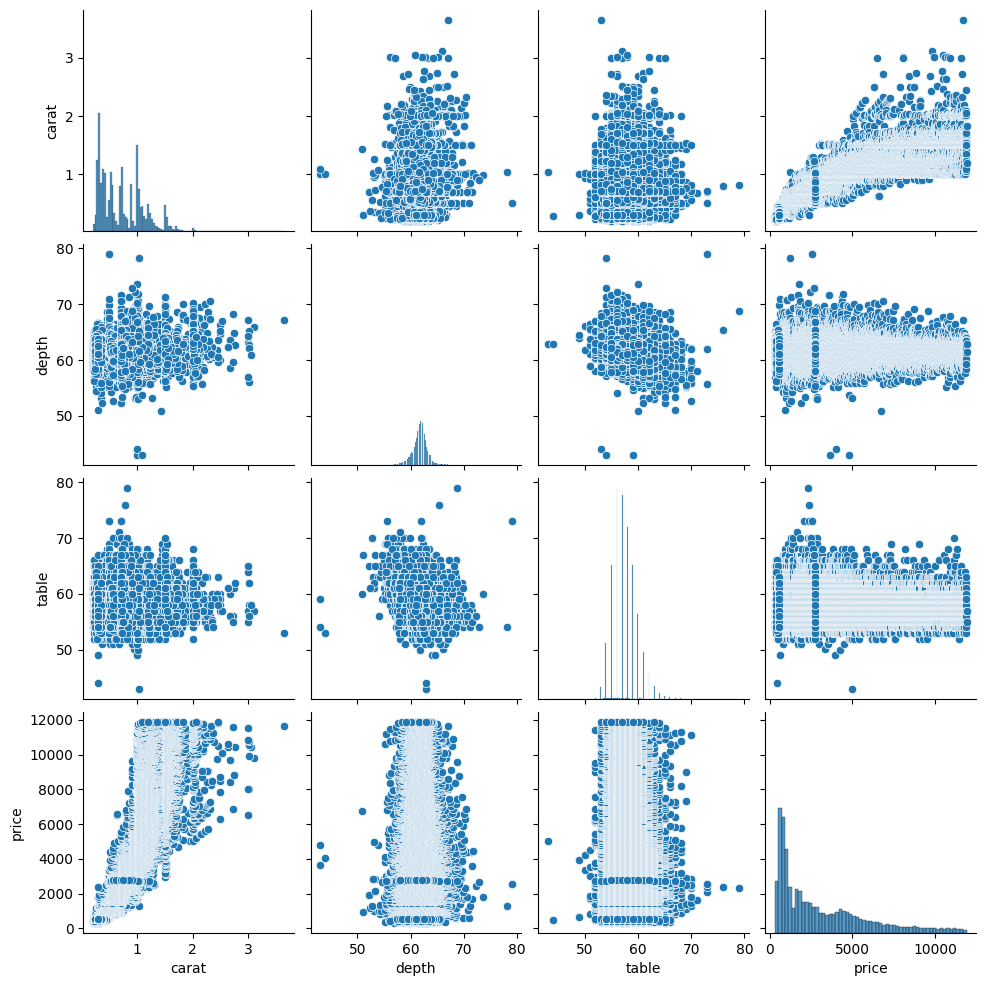

In [34]:
sns.pairplot(df[['carat','depth','table','price']])
plt.show()